In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import numpy as np
import re
import wandb


In [2]:
from datasets import load_dataset

# Load the math dataset from Hugging Face
dataset = load_dataset("lighteval/MATH", split="test")
print(dataset)
print(dataset[0])
for i in range(10):
    print(len(dataset[i]['problem']))

dataset = load_dataset("lighteval/MATH", split="all")
print(dataset)
print(dataset[0])
for i in range(7500,7510):
    print(len(dataset[i]['problem']))   


/ssdscratch/byuan48/software/anaconda3/envs/reasoning/lib/python3.9/site-packages/datasets/load.py:1429: FutureWarning: The repository for lighteval/MATH contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/lighteval/MATH
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 5000
})
{'problem': 'How many vertical asymptotes does the graph of $y=\\frac{2}{x^2+x-6}$ have?', 'level': 'Level 3', 'type': 'Algebra', 'solution': 'The denominator of the rational function factors into $x^2+x-6=(x-2)(x+3)$. Since the numerator is always nonzero, there is a vertical asymptote whenever the denominator is $0$, which occurs for $x = 2$ and $x = -3$.  Therefore, the graph has $\\boxed{2}$ vertical asymptotes.'}
74
72
91
30
39
69
103
253
240
108


/ssdscratch/byuan48/software/anaconda3/envs/reasoning/lib/python3.9/site-packages/datasets/load.py:1429: FutureWarning: The repository for lighteval/MATH contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/lighteval/MATH
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 12500
})
{'problem': 'Let \\[f(x) = \\left\\{\n\\begin{array}{cl} ax+3, &\\text{ if }x>2, \\\\\nx-5 &\\text{ if } -2 \\le x \\le 2, \\\\\n2x-b &\\text{ if } x <-2.\n\\end{array}\n\\right.\\]Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).', 'level': 'Level 5', 'type': 'Algebra', 'solution': 'For the piecewise function to be continuous, the cases must "meet" at $2$ and $-2$. For example, $ax+3$ and $x-5$ must be equal when $x=2$. This implies $a(2)+3=2-5$, which we solve to get $2a=-6 \\Rightarrow a=-3$. Similarly, $x-5$ and $2x-b$ must be equal when $x=-2$. Substituting, we get $-2-5=2(-2)-b$, which implies $b=3$. So $a+b=-3+3=\\boxed{0}$.'}
74
72
91
30
39
69
103
253
240
108


In [3]:
levels = {'1': 0, '2': 0, '3': 0, '4': 0, '5': 0}
# debug the following command
potential_indices = np.random.choice(12500,100)
for i in range(12500):
    if '1' in dataset[i]['level']:
        levels['1'] += 1
    if '2' in dataset[i]['level']:
        levels['2'] += 1
    if '3' in dataset[i]['level']:
        levels['3'] += 1
    if '4' in dataset[i]['level']:
        levels['4'] += 1
    if '5' in dataset[i]['level']:
        levels['5'] += 1
    if i in potential_indices:
        print(f'current index: {i}')
        # print the propotion of each level
        print(f'Level 1: {levels["1"]/i}')
        print(f'Level 2: {levels["2"]/i}')
        print(f'Level 3: {levels["3"]/i}')
        print(f'Level 4: {levels["4"]/i}')
        print(f'Level 5: {levels["5"]/i}')
print(levels)


current index: 87
Level 1: 0.08045977011494253
Level 2: 0.13793103448275862
Level 3: 0.3103448275862069
Level 4: 0.26436781609195403
Level 5: 0.21839080459770116
current index: 238
Level 1: 0.09243697478991597
Level 2: 0.19747899159663865
Level 3: 0.25210084033613445
Level 4: 0.2647058823529412
Level 5: 0.19747899159663865
current index: 263
Level 1: 0.10646387832699619
Level 2: 0.20532319391634982
Level 3: 0.23954372623574144
Level 4: 0.24714828897338403
Level 5: 0.20532319391634982
current index: 334
Level 1: 0.10778443113772455
Level 2: 0.20958083832335328
Level 3: 0.23652694610778444
Level 4: 0.23652694610778444
Level 5: 0.2125748502994012
current index: 357
Level 1: 0.10084033613445378
Level 2: 0.21008403361344538
Level 3: 0.23249299719887956
Level 4: 0.23529411764705882
Level 5: 0.22408963585434175
current index: 448
Level 1: 0.09821428571428571
Level 2: 0.203125
Level 3: 0.22767857142857142
Level 4: 0.22767857142857142
Level 5: 0.24553571428571427
current index: 492
Level 1: 0.0

In [4]:
import json
import torch
from utils import check_equivalence

def load_jsonl(file_path):
    """
    Load a JSONL file containing input and solutions.
    Args:
        file_path (str): Path to the JSONL file.
    Returns:
        data (list): List of dictionaries with input string and solutions.
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data

def load_pt(file_path):
    """
    Load a .pt file using PyTorch.
    Args:
        file_path (str): Path to the .pt file.
    Returns:
        tensor (torch.Tensor): The loaded tensor.
    """
    tensor = torch.load(file_path)
    return tensor

# Example usage
jsonl_file = '/ssdscratch/byuan48/Reasoning/Llama-3.2-3B-Instruct_answer.jsonl'  # Replace with the actual JSONL file path
pt_file = '/ssdscratch/byuan48/Reasoning/Llama-3.2-3B-Instruct_log_probs.pt'       # Replace with the actual .pt file path

# Load the .pt file
tensor_data = load_pt(pt_file)
print(f"Loaded tensor shape: {tensor_data.shape}")

# Load the JSONL file
jsonl_data = load_jsonl(jsonl_file)
details = []
for item in jsonl_data:
    input_string = item.get("input", "")
    solutions = item.get("solutions", [])
    sign, detail = check_equivalence(solutions,input_string[0])
    print(solutions)
    print(input_string)
    details.append(detail)


/tmp/ipykernel_676221/4054411427.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(file_path)
/ssdscratch/byuan48/software/anaconda3/envs/reasoning/li

Loaded tensor shape: torch.Size([1000, 8, 1024])
['0.05', '0.44', '0.86', '0.02', '0.01', None, None, '0.04']
['0.61']
Error parsing answer '\frac19': LaTeX parsing requires the antlr4 Python package, provided by pip (antlr4-python3-runtime) or conda (antlr-python-runtime), version 4.11
['\\frac{1}{900}', '\\frac{1}{11}', '\\frac{1}{9}', None, None, None, '\\frac{1}{18}', '\\frac{1}{9}']
['\\frac19']
['3', '2', '1', None, None, '3', '1', '3']
['1']
Error parsing expression '\csc x + \sec x': Sympify of expression 'could not parse '\\csc x + \\sec x'' failed, because of exception being raised:
SyntaxError: unexpected character after line continuation character (<string>, line 1); using the original text.
Error parsing expression '4 \csc^2 2x': Sympify of expression 'could not parse '4 \\csc^2 2x'' failed, because of exception being raised:
SyntaxError: unexpected character after line continuation character (<string>, line 1); using the original text.
Error parsing expression '\frac{4}{\

In [5]:
import torch
import numpy as np

tensor_data[tensor_data==100] = float('nan')
ppl = torch.nanmean(tensor_data, dim=-1)

ppl_values = ppl.numpy()  
details_array = np.array(details)  

ppl_true = ppl_values[details_array == True]
ppl_false = ppl_values[details_array == False]

print(f"Mean for True: {np.mean(ppl_true):.2f}, Mean for False: {np.mean(ppl_false):.2f}")
print(f"Median for True: {np.median(ppl_true):.2f}, Median for False: {np.median(ppl_false):.2f}")

threshold = (np.mean(ppl_true) + np.mean(ppl_false)) / 2
predicted_details = ppl_values > threshold
accuracy = np.mean(predicted_details == details_array)
print(f"Prediction accuracy: {accuracy * 100:.2f}%")



Mean for True: -0.19, Mean for False: -0.25
Median for True: -0.17, Median for False: -0.23
Prediction accuracy: 62.08%


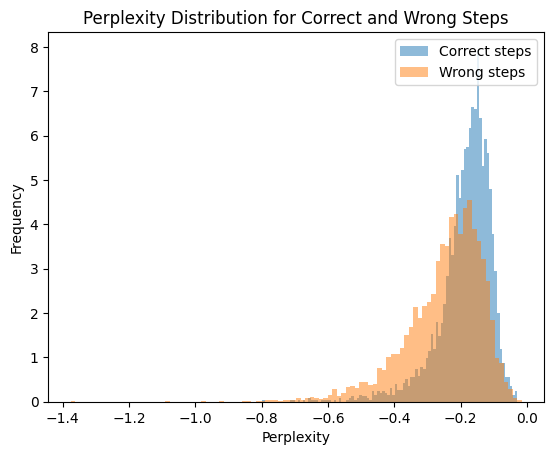

In [7]:
# plt histogram of ppl_true and ppl_false
import matplotlib.pyplot as plt

plt.hist(ppl_true, bins=100, alpha=0.5, label='Correct steps',density=True)
plt.hist(ppl_false, bins=100, alpha=0.5, label='Wrong steps',density=True)
plt.legend(loc='upper right')
plt.xlabel('Perplexity')
plt.ylabel('Frequency')
plt.title('Perplexity Distribution for Correct and Wrong Steps')
plt.show()

In [8]:
correct_max = 0;correct_min=0
for index, (detail, ppl_value) in enumerate(zip(details,ppl_values)):
    # find the index of the largest value in each ppl_value
    max_index = np.argmax(ppl_value)
    # find the index of the smallest value in each ppl_value
    min_index = np.argmin(ppl_value)
    correct_max += 1 if detail[max_index] else 0
    correct_min += 1 if detail[min_index] else 0
print(f"Accuracy by choosing answers with low ppl: {correct_max/len(details)}")
print(f"Accuracy by choosing answers with high ppl: {correct_min/len(details)}")



Accuracy by choosing answers with low ppl: 0.454
Accuracy by choosing answers with high ppl: 0.304
